In [1]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale
from dask.diagnostics import ProgressBar

In [2]:
# 8 Year
Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975TempOnlyEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr'
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr'

# Repeats
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 30 warming 
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce15x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 15 warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce7_5x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth' # temp 7.5 warming

# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming

In [3]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=False
emulation_stability_long=False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name
if emulation_stability:
    # dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
    #     68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
    #    133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
    #    198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
    #    263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
       # 328, 333, 338, 343, 348, 353, 358, 363])
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
    for i in range(1,repeats):
        new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
    # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time[:7300]
    # ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 3853))
elif emulation_stability_long:
    repeats = 3000
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = np.arange(ds_groundtruth.time.size*repeats)
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 30000))

else:
    ds_groundtruth = ds_input.sel(time=slice("1975-01-01", None))
    ds_groundtruth = ds_groundtruth.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ['thetao', 'so', 'zos']
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

if os.path.isdir(output_path_all):
    print("Using Output Folder : ", output_path_all)
else:
    print("Using Output Folder : ../outputs")
    output_path_all = "../outputs"

if os.path.isdir(output_path_temp):
    print("Using Output Folder : ", output_path_temp)
else:
    print("Using Output Folder : ../outputs")
    output_path_temp = "../outputs"

ds_prediction_raw_all = xr.open_zarr(Pred_path_all)

ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_all_raw.time.size))

# ds_prediction_all = post_processor(
#     ds_prediction_raw_all, ds_groundtruth, ls_all
# )
min_time = min(ds_prediction_raw_all.time.size, min(ds_prediction_raw_temp.time.size, ds_groundtruth.time.size))
ds_prediction_all = post_processor(
    ds_prediction_raw_all.isel(time = slice(0,min_time)), ds_groundtruth.isel(time = slice(0,min_time)), ls_all
)

ds_prediction_temp = post_processor(
    ds_prediction_raw_temp.isel(time = slice(0,min_time)), ds_groundtruth.isel(time = slice(0,min_time)), ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)
ds_groundtruth = ds_groundtruth.transpose('time','lev',...)

Using Output Folder :  ./temp/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55
Using Output Folder :  ./temp/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55


In [4]:
# ds_prediction_all = ds_prediction_all.isel(time=slice(7000,None))
# ds_prediction_temp = ds_prediction_temp.isel(time=slice(7000,7000+ds_prediction_all.time.size))


In [5]:
ds_prediction_all

<xarray.Dataset>
Dimensions:         (time: 600, y: 180, x: 360, lev: 19, y_b: 181, x_b: 361)
Coordinates:
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * time            (time) object 2014-10-10 12:00:00 ... 2022-12-24 12:00:00
Dimensions without coordinates: y_b, x_b
Data variables:
    uo              (time, lev, y, x) float64 dask.array<chunksize=(75, 10, 23, 45), meta=np.ndarray>
    vo              (time, lev, y, x) float64 dask.array<chunksize=(75, 1, 23, 45), meta=np.ndarray>
    thetao          (time, lev, y, x) float64 dask.array<chunksize=(75, 2, 23, 45), meta=np.ndarray>
    so              (time, lev, y, x) float64 dask.array<chunksize=(75, 3, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float64 dask.array<chunksize=(75, 23, 45), meta=np.ndarray>

In [6]:
ds_prediction_temp

<xarray.Dataset>
Dimensions:         (time: 600, y: 180, x: 360, lev: 19, y_b: 181, x_b: 361)
Coordinates:
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * time            (time) object 2014-10-10 12:00:00 ... 2022-12-24 12:00:00
Dimensions without coordinates: y_b, x_b
Data variables:
    thetao          (time, lev, y, x) float64 dask.array<chunksize=(75, 10, 23, 45), meta=np.ndarray>
    so              (time, lev, y, x) float64 dask.array<chunksize=(75, 1, 23, 45), meta=np.ndarray>
    zos             (time, y, x) float64 dask.array<chunksize=(75, 23, 45), meta=np.ndarray>

In [7]:
ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude')
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude')
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_prediction_all['zos'] = ds_prediction_all['zos'].assign_attrs(long_name = r"SSH", units = r"m")
ds_prediction_all['uo'] = ds_prediction_all['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
ds_prediction_all['vo'] = ds_prediction_all['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")

ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude')
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude')
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_prediction_temp['zos'] = ds_prediction_temp['zos'].assign_attrs(long_name = r"SSH", units = r"m")

ds_groundtruth['y']  = ds_groundtruth.y.assign_attrs(long_name='latitude')
ds_groundtruth['x']  = ds_groundtruth.x.assign_attrs(long_name='longitude')
ds_groundtruth['thetao'] = ds_groundtruth['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")
ds_groundtruth['zos'] = ds_groundtruth['zos'].assign_attrs(long_name = r"SSH", units = r"m")
ds_groundtruth['uo'] = ds_groundtruth['uo'].assign_attrs(long_name = r"${u}$", units = r"m/s")
ds_groundtruth['vo'] = ds_groundtruth['vo'].assign_attrs(long_name = r"${v}$", units = r"m/s")

In [8]:
color_1 = '#DE3A41'
color_2 = '#277DC7'

In [9]:
def remove_climatology(ds, var='zos'):
    ssh = ds[var].copy()
    
    # Compute the climatology
    climatology = ssh.groupby('time.dayofyear').mean('time').compute()

    # Remove the seasonal cycle 
    day_of_year = ssh['time'].dt.dayofyear
    ssh = ds[var] - climatology.sel(dayofyear=day_of_year)
    
    return ssh.compute(), climatology

def detrend_and_remove_climatology(ds, var='zos'):    
    # Detrend the data
    poly_coeffs = ds[var].polyfit(dim='time', deg=1)
    trend = xr.polyval(ds['time'], poly_coeffs.polyfit_coefficients).compute()
    
    # Remove the trend from the original data
    ssh_detrended = ds[var] - trend

    # Compute the climatology on the detrended data
    climatology = ssh_detrended.groupby('time.dayofyear').mean('time').compute()

    # Remove the seasonal cycle (climatology) from the detrended data
    day_of_year = ssh_detrended['time'].dt.dayofyear
    ssh_final = (ssh_detrended - climatology.sel(dayofyear=day_of_year)).compute()
    
    return ssh_final, climatology, trend

In [10]:
with ProgressBar():
    ssh_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth)
    ssh_prediction_temp, _, _ = detrend_and_remove_climatology(ds_prediction_temp)
    ssh_prediction_all, _, _ = detrend_and_remove_climatology(ds_prediction_all)

[########################################] | 100% Completed | 5.06 sms
[########################################] | 100% Completed | 1.25 sms
[########################################] | 100% Completed | 101.18 ms
[########################################] | 100% Completed | 100.89 ms
[########################################] | 100% Completed | 101.10 ms
[########################################] | 100% Completed | 1.18 sms
[########################################] | 100% Completed | 9.28 sms
[########################################] | 100% Completed | 31.40 s
[########################################] | 100% Completed | 103.70 ms
[########################################] | 100% Completed | 100.88 ms
[########################################] | 100% Completed | 101.04 ms
[########################################] | 100% Completed | 1.59 sms
[########################################] | 100% Completed | 9.19 sms
[########################################] | 100% Completed | 32.20 s
[#

In [15]:
with ProgressBar():
    sst_2_5_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=2.5), 'thetao')
    sst_2_5_prediction_temp, _, _ = detrend_and_remove_climatology(ds_prediction_temp.sel(lev=2.5), 'thetao')
    sst_2_5_prediction_all, _, _ = detrend_and_remove_climatology(ds_prediction_all.sel(lev=2.5), 'thetao')

[########################################] | 100% Completed | 101.40 ms
[########################################] | 100% Completed | 5.16 sms
[########################################] | 100% Completed | 101.26 ms
[########################################] | 100% Completed | 1.43 sms
[########################################] | 100% Completed | 101.25 ms
[########################################] | 100% Completed | 101.03 ms
[########################################] | 100% Completed | 101.10 ms
[########################################] | 100% Completed | 101.14 ms
[########################################] | 100% Completed | 100.95 ms
[########################################] | 100% Completed | 1.22 sms
[########################################] | 100% Completed | 101.83 ms
[########################################] | 100% Completed | 10.25 ss
[########################################] | 100% Completed | 102.72 ms
[########################################] | 100% Completed | 32.95 

In [16]:
with ProgressBar():
    sst_550_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=550), 'thetao')
    sst_550_prediction_temp, _, _ = detrend_and_remove_climatology(ds_prediction_temp.sel(lev=550), 'thetao')
    sst_550_prediction_all, _, _ = detrend_and_remove_climatology(ds_prediction_all.sel(lev=550), 'thetao')

[########################################] | 100% Completed | 101.37 ms
[########################################] | 100% Completed | 4.78 sms
[########################################] | 100% Completed | 101.33 ms
[########################################] | 100% Completed | 1.33 sms
[########################################] | 100% Completed | 101.45 ms
[########################################] | 100% Completed | 100.94 ms
[########################################] | 100% Completed | 100.94 ms
[########################################] | 100% Completed | 101.13 ms
[########################################] | 100% Completed | 100.97 ms
[########################################] | 100% Completed | 1.52 sms
[########################################] | 100% Completed | 101.28 ms
[########################################] | 100% Completed | 8.46 sms
[########################################] | 100% Completed | 101.26 ms
[########################################] | 100% Completed | 34.17 

In [17]:
with ProgressBar():
    sst_1400_groundtruth, _, _ = detrend_and_remove_climatology(ds_groundtruth.sel(lev=1400), 'thetao')
    sst_1400_prediction_temp, _, _ = detrend_and_remove_climatology(ds_prediction_temp.sel(lev=1400), 'thetao')
    sst_1400_prediction_all, _, _ = detrend_and_remove_climatology(ds_prediction_all.sel(lev=1400), 'thetao')

[########################################] | 100% Completed | 101.11 ms
[########################################] | 100% Completed | 4.55 sms
[########################################] | 100% Completed | 101.23 ms
[########################################] | 100% Completed | 1.53 sms
[########################################] | 100% Completed | 101.15 ms
[########################################] | 100% Completed | 100.87 ms
[########################################] | 100% Completed | 100.91 ms
[########################################] | 100% Completed | 100.87 ms
[########################################] | 100% Completed | 100.93 ms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 101.29 ms
[########################################] | 100% Completed | 7.49 sms
[########################################] | 100% Completed | 101.19 ms
[########################################] | 100% Completed | 30.33 

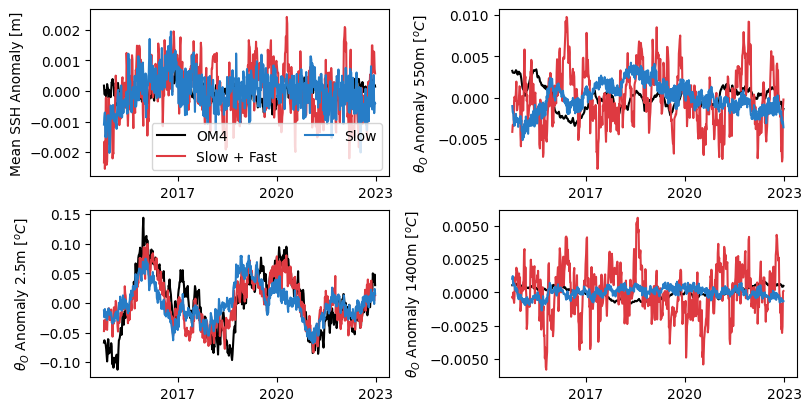

In [48]:
fig, axs = plt.subplots(2,2,figsize=(8,4),layout="constrained",gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5], 'wspace': 0.05,'hspace':.05})

ssh_groundtruth_ts = (ssh_groundtruth*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])
ssh_prediction_temp_ts = (ssh_prediction_temp*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])
ssh_prediction_all_ts = (ssh_prediction_all*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])

ssh_groundtruth_ts = ssh_groundtruth_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')
ssh_prediction_all_ts = ssh_prediction_all_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')
ssh_prediction_temp_ts = ssh_prediction_temp_ts.assign_attrs(long_name = 'Mean SSH Anomaly', units = 'm').rename('Mean SSH Anomaly')

ssh_groundtruth_ts.plot(ax = axs[0,0], label = 'OM4', c= 'k')
ssh_prediction_all_ts.plot(ax = axs[0,0],label = 'Slow + Fast', c = color_1)
ssh_prediction_temp_ts.plot(ax = axs[0,0],label = 'Slow', c = color_2)
axs[0,0].legend(ncol=2,loc = 'lower right')
axs[0,0].set_xlabel('')

count = 0
for depth in [2.5,  550, 1400]:
    if count == 0:
        ax = axs[1,0]
        anoms = sst_2_5_groundtruth
        anoms_all = sst_2_5_prediction_all
        anoms_temp = sst_2_5_prediction_temp
    elif count == 1:
        ax = axs[0,1]
        anoms = sst_550_groundtruth
        anoms_all = sst_550_prediction_all
        anoms_temp = sst_550_prediction_temp
    else:
        ax = axs[1,1]
        anoms = sst_1400_groundtruth
        anoms_all = sst_1400_prediction_all
        anoms_temp = sst_1400_prediction_temp

    
    anoms_time_series = (anoms*ds_groundtruth['areacello']).sum(['x','y'])/ds_groundtruth['areacello'].sum()
    anoms_all_time_series = (anoms_all*ds_groundtruth['areacello']).sum(['x','y'])/ds_groundtruth['areacello'].sum()
    anoms_temp_time_series = (anoms_temp*ds_groundtruth['areacello']).sum(['x','y'])/ds_groundtruth['areacello'].sum()

    anoms_time_series = anoms_time_series.assign_attrs(long_name = r"$\theta_O$ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')
    anoms_all_time_series = anoms_all_time_series.assign_attrs(long_name = r"$\theta_O $ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')
    anoms_temp_time_series = anoms_temp_time_series.assign_attrs(long_name = r"$\theta_O $ Anomaly "+str(depth) +"m", units = r"$^oC$").rename('Mean SSH Anomaly')

    count += 1

    anoms_time_series.plot(ax = ax, label = 'OM4', c= 'k')
    anoms_all_time_series.plot(ax = ax,label = 'Slow + Fast', c = color_1)
    anoms_temp_time_series.plot(ax = ax,label = 'Slow', c = color_2)
    ax.set_xlabel('')
    ax.set_title('')

plt.savefig("../Figures/anomalies_SSH_and_temp.png", bbox_inches='tight',dpi = 150)


In [67]:
ssh_groundtruth = ssh_groundtruth.assign_attrs(long_name = 'SSH Std', units = 'm').rename('SSH Std')
ssh_prediction_all = ssh_prediction_all.assign_attrs(long_name = 'SSH Std', units = 'm').rename('SSH Std')
ssh_prediction_temp = ssh_prediction_temp.assign_attrs(long_name = 'SSH Std', units = 'm').rename('SSH Std')

sst_2_5_groundtruth = sst_2_5_groundtruth.assign_attrs(long_name = r"$\theta_O$ Std 2.5m", units = r"$^oC$").rename(r"$\theta_O$ Std 2.5m")
sst_2_5_prediction_temp = sst_2_5_prediction_temp.assign_attrs(long_name = r"$\theta_O $ Std 2.5m", units = r"$^oC$").rename(r"$\theta_O $ Std 2.5m")
sst_2_5_prediction_all = sst_2_5_prediction_all.assign_attrs(long_name = r"$\theta_O $ Std 2.5m", units = r"$^oC$").rename(r"$\theta_O $ Std 2.5m")

sst_550_groundtruth = sst_550_groundtruth.assign_attrs(long_name = r"$\theta_O$ Std 550m", units = r"$^oC$").rename(r"$\theta_O$ Std 550m")
sst_550_prediction_temp = sst_550_prediction_temp.assign_attrs(long_name = r"$\theta_O $ Std 550m", units = r"$^oC$").rename(r"$\theta_O$ Std 550m")
sst_550_prediction_all = sst_550_prediction_all.assign_attrs(long_name = r"$\theta_O $ Std 550m", units = r"$^oC$").rename(r"$\theta_O$ Std 550m")

sst_1400_groundtruth = sst_1400_groundtruth.assign_attrs(long_name = r"$\theta_O$ Std 1400m", units = r"$^oC$").rename(r"$\theta_O$ Std 1400m")
sst_1400_prediction_temp = sst_1400_prediction_temp.assign_attrs(long_name = r"$\theta_O $ Std 1400m", units = r"$^oC$").rename(r"$\theta_O$ Std 1400m")
sst_1400_prediction_all = sst_1400_prediction_all.assign_attrs(long_name = r"$\theta_O $ Std 1400m", units = r"$^oC$").rename(r"$\theta_O$ Std 1400m")


In [68]:
def plot_map(anoms, anoms_all, anoms_temp, name):
    new_cmap = cm.cm.thermal 
    
    new_cmap.set_bad('grey',.6)
    
    vmin = 0
    vmax = np.nanmax(anoms.std('time'))/2
    fig, ax = plt.subplots(3,1,figsize=(5,8),layout="constrained",gridspec_kw={'width_ratios': [1], 'height_ratios': [.9,.9,.9], 'wspace': 0.05,'hspace':.05})
        
    anoms.std('time').plot(ax=ax[0],add_colorbar=True, cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[0].set_title('OM4')
    
    pred_plot_all = anoms_all.std('time').plot(ax=ax[1],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[1].set_title('Slow + Fast')
    
    pred_plot_temp = anoms_temp.std('time').plot(ax=ax[2],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
    ax[2].set_title('Slow')

    plt.savefig(f"../Figures/{name}", bbox_inches='tight',dpi = 150)

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


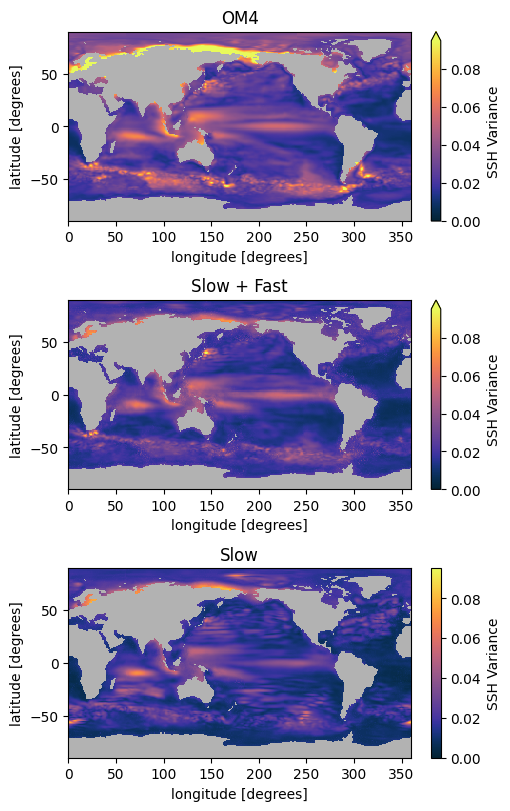

In [69]:
plot_map(ssh_groundtruth, ssh_prediction_all, ssh_prediction_temp, name='SSH_var_Map')

In [70]:
def plot_3x3_map(anoms_list, anoms_all_list, anoms_temp_list, name):
    new_cmap = cm.cm.thermal 
    
    new_cmap.set_bad('grey',.6)
    
    fig, ax = plt.subplots(3,3,figsize=(12,8),layout="constrained",gridspec_kw={'width_ratios': [.9, .9, .9], 'height_ratios': [.9,.9,.9], 'wspace': 0.05,'hspace':.05})
    ax_flat = ax.flatten()

    for i in range(3):
        anoms = anoms_list[i]
        anoms_all = anoms_all_list[i]
        anoms_temp = anoms_temp_list[i]

        vmin = 0
        vmax = np.nanmax(anoms.std('time'))/2
        
        anoms.std('time').plot(ax=ax_flat[i],add_colorbar=True, cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i].set_title('OM4')
        
        pred_plot_all = anoms_all.std('time').plot(ax=ax_flat[i+3],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i+3].set_title('Slow + Fast')
        
        pred_plot_temp = anoms_temp.std('time').plot(ax=ax_flat[i+6],add_colorbar=True,cmap = new_cmap, vmin = vmin,vmax = vmax)
        ax_flat[i+6].set_title('Slow')

    plt.savefig(f"../Figures/{name}", bbox_inches='tight',dpi = 150)

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dt

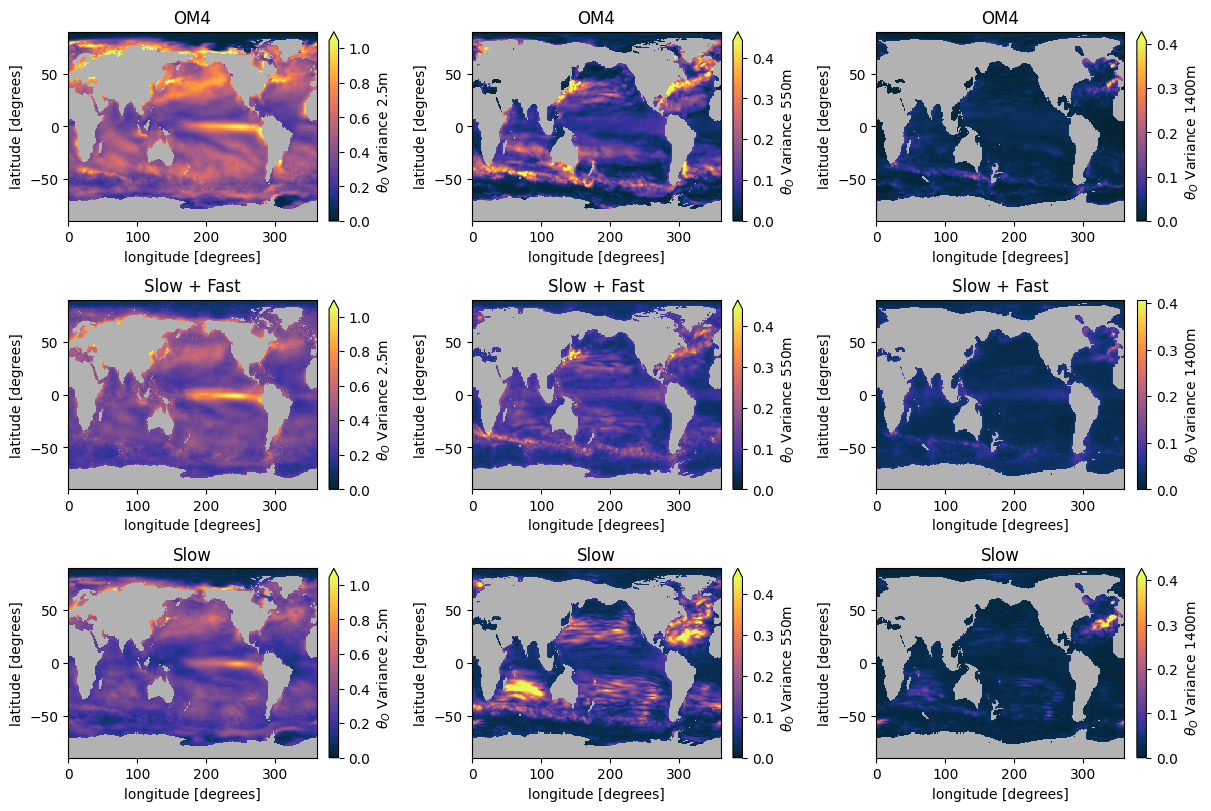

In [71]:
plot_3x3_map(
    [sst_2_5_groundtruth, sst_550_groundtruth, sst_1400_groundtruth], 
    [sst_2_5_prediction_all, sst_550_prediction_all, sst_1400_prediction_all], 
    [sst_2_5_prediction_temp, sst_550_prediction_temp, sst_1400_prediction_temp], "Temps_var_Map")

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=a

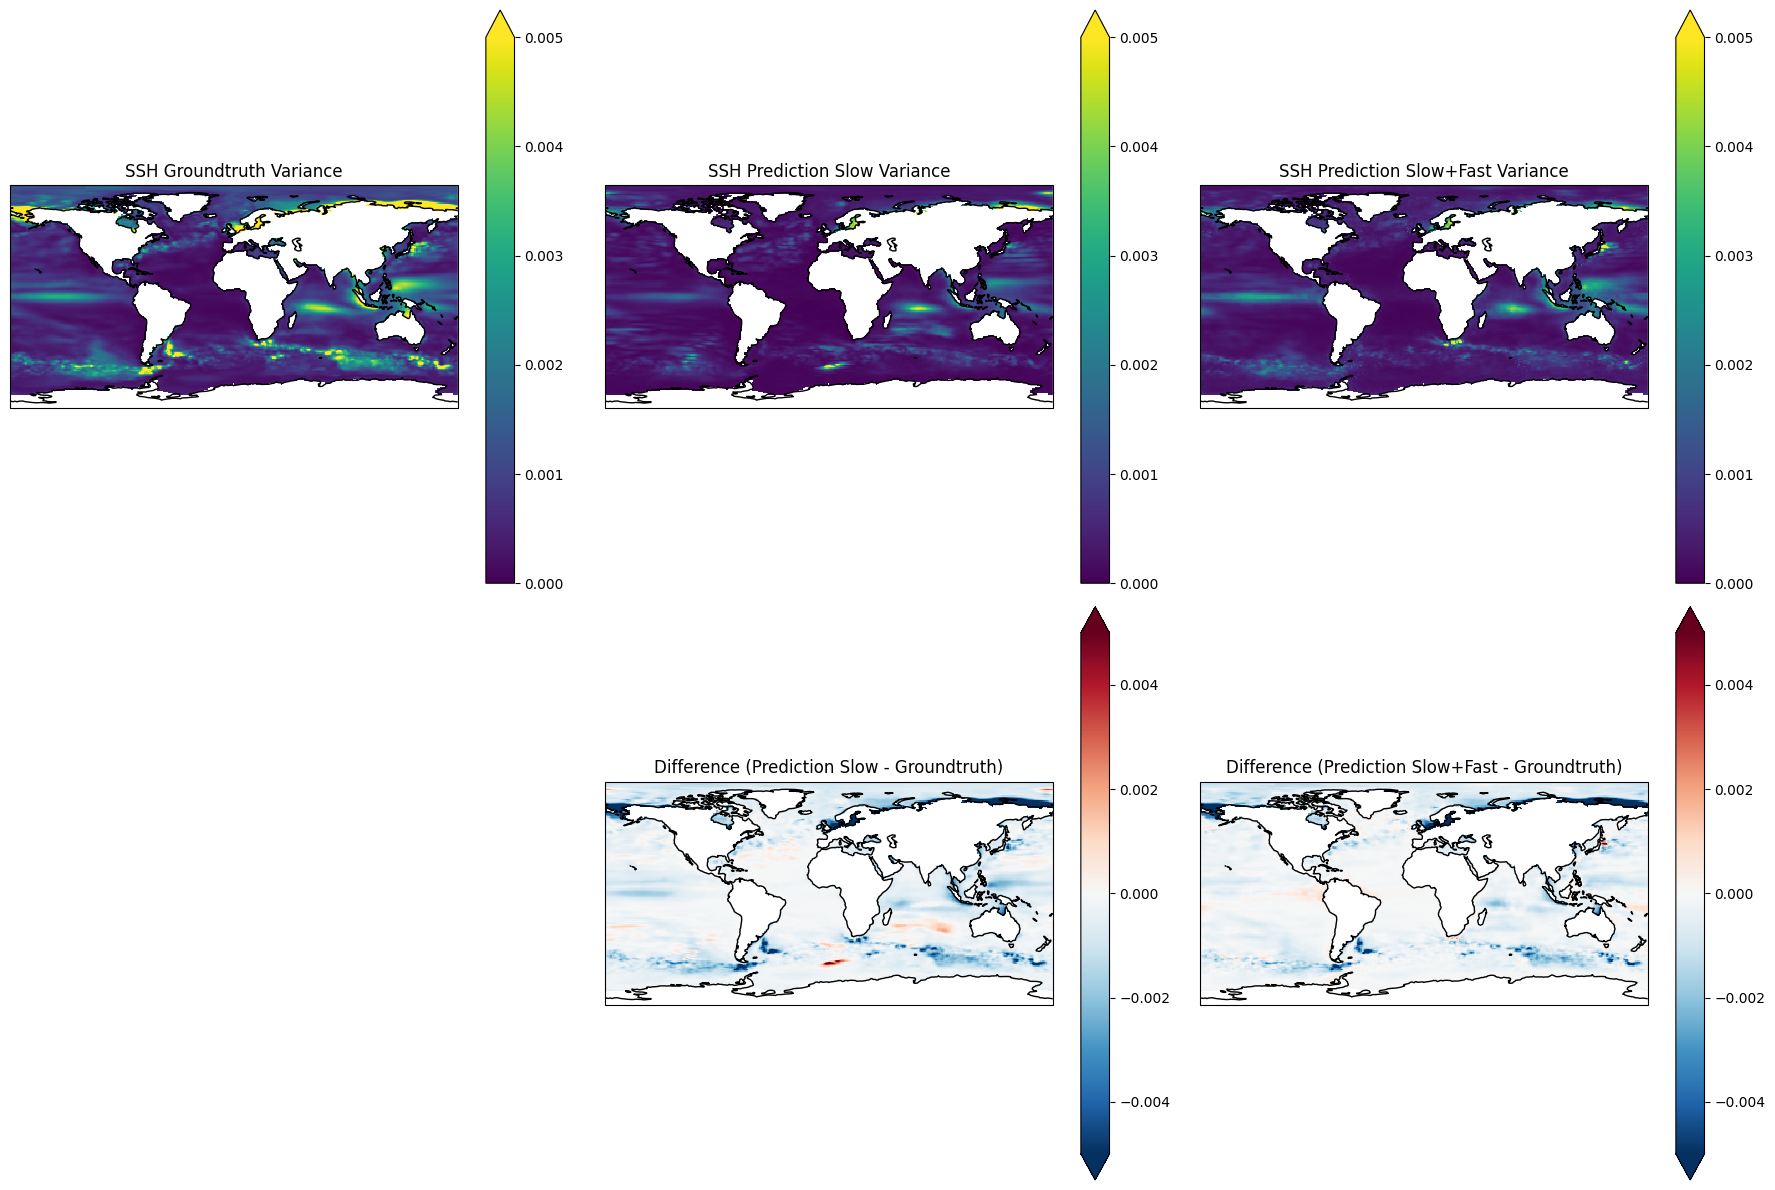

In [25]:
# Define a much smaller range for the colorbar
vmin = 0  # Minimum colorbar value
vmax = 0.005  # Maximum colorbar value

# Define the figure with 3 columns and 2 rows (for the variance and difference plots)
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Row 1 - Variance plots

# Compute and plot the variance of ssh_groundtruth over time with the reduced colorbar range
ssh_groundtruth.var('time').plot(ax=axs[0, 0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('SSH Groundtruth Variance')
axs[0, 0].coastlines()

# Compute and plot the variance of ssh_prediction_temp over time with the reduced colorbar range
ssh_prediction_temp.var('time').plot(ax=axs[0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('SSH Prediction Slow Variance')
axs[0, 1].coastlines()

# Compute and plot the variance of ssh_prediction_all over time with the reduced colorbar range
ssh_prediction_all.var('time').plot(ax=axs[0, 2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 2].set_title('SSH Prediction Slow+Fast Variance')
axs[0, 2].coastlines()

# Row 2 - Difference plots

# Compute and plot the difference: ssh_groundtruth - ssh_prediction_temp
(ssh_prediction_temp.var('time') - ssh_groundtruth.var('time')).plot(ax=axs[1, 1], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 1].set_title('Difference (Prediction Slow - Groundtruth)')
axs[1, 1].coastlines()

# Compute and plot the difference: ssh_groundtruth - ssh_prediction_all
(ssh_prediction_all.var('time') - ssh_groundtruth.var('time')).plot(ax=axs[1, 2], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 2].set_title('Difference (Prediction Slow+Fast - Groundtruth)')
axs[1, 2].coastlines()

# Remove the first column in the second row (to keep the layout clean)
axs[1, 0].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

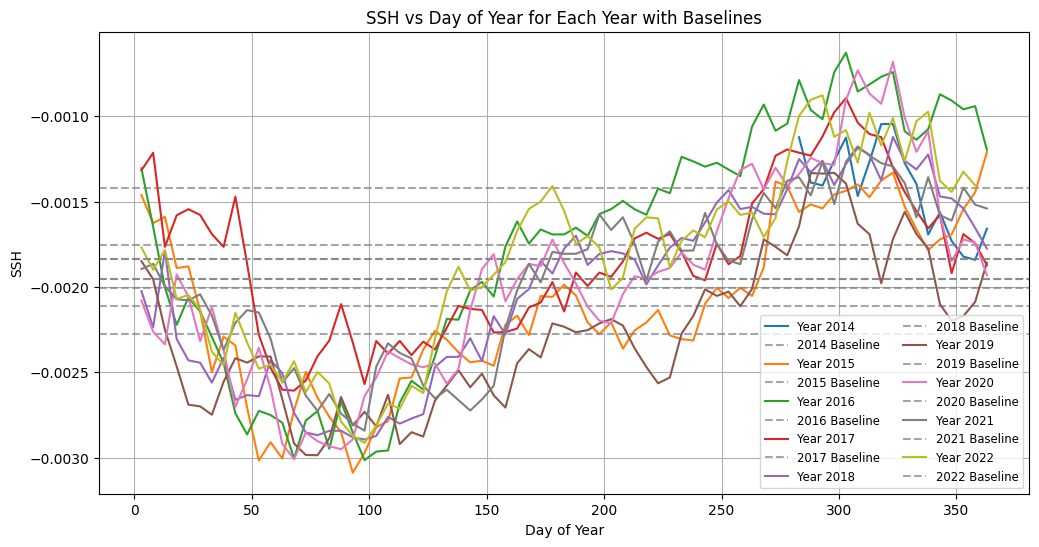

In [38]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# First group by year and yearday
global_average_ssh = ((ds_groundtruth['zos']*ds_groundtruth.areacello).sum(["x","y"])/ds_groundtruth.areacello.sum(["x","y"])).compute()
ssh_by_year = global_average_ssh.groupby('time.year')
ssh_by_yearday = global_average_ssh.groupby('time.dayofyear')

# Set up the plot
plt.figure(figsize=(12, 6))

# Iterate over each year group and plot
for year, data in ssh_by_year:
    # Extract day of year and corresponding SSH anomalies
    yearday = data['time'].dt.dayofyear
    ssh_values = data.values
    
    # Plot the SSH anomalies against yearday for the current year
    plt.plot(yearday, ssh_values, label=f'Year {year}')
    
    # Compute the yearly mean (baseline) and plot as a horizontal line
    yearly_mean = ssh_values.mean()
    plt.axhline(y=yearly_mean, color='gray', linestyle='--', alpha=0.7, label=f'{year} Baseline')

plt.xlabel('Day of Year')
plt.ylabel('SSH')
plt.title('SSH vs Day of Year for Each Year with Baselines')
plt.legend(loc='best', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

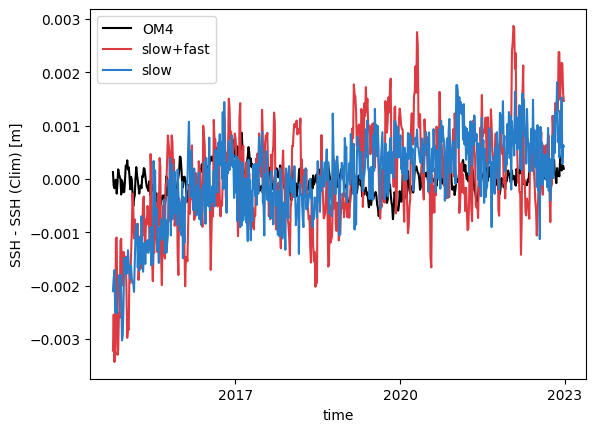

In [118]:
ssh_groundtruth = ssh_groundtruth.rename('SSH - SSH (Clim)')
ssh_groundtruth = ssh_groundtruth.assign_attrs(units = 'm')
ssh_groundtruth.plot(label="OM4", c='k')

ssh_prediction_all = ssh_prediction_all.rename('SSH - SSH (Clim)')
ssh_prediction_all = ssh_prediction_all.assign_attrs(units = 'm')
ssh_prediction_all.plot(label="slow+fast", c=color_1)

ssh_prediction_temp = ssh_prediction_temp.rename('SSH - SSH (Clim)')
ssh_prediction_temp = ssh_prediction_temp.assign_attrs(units = 'm')
ssh_prediction_temp.plot(label="slow", c=color_2)

plt.legend()
plt.show()

In [9]:
sst_groundtruth, _ = remove_climatology(ds_groundtruth.isel(lev=0), 'thetao')
sst_prediction_temp, _ = remove_climatology(ds_prediction_temp.isel(lev=0), 'thetao')
sst_prediction_all, _ = remove_climatology(ds_prediction_all.isel(lev=0), 'thetao')

<xarray.DataArray 'thetao' (dayofyear: 73, y: 180, x: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7334474, -1.7339606, -1.7345307, ..., -1.7320318,
         -1.7324579, -1.732934 ],
        [-1.7425435, -1.7430298, -1.74352  , ..., -1.7408862,
         -1.7414427, -1.7419982],
        [-1.7324204, -1.732846 , -1.7332356, ..., -1.7311591,
         -1.7316117, -1.7320237]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7319088, -1.7324159, -1.7329793, ..., -1.7304

/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/xarray/core/nputils.py:177: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=a

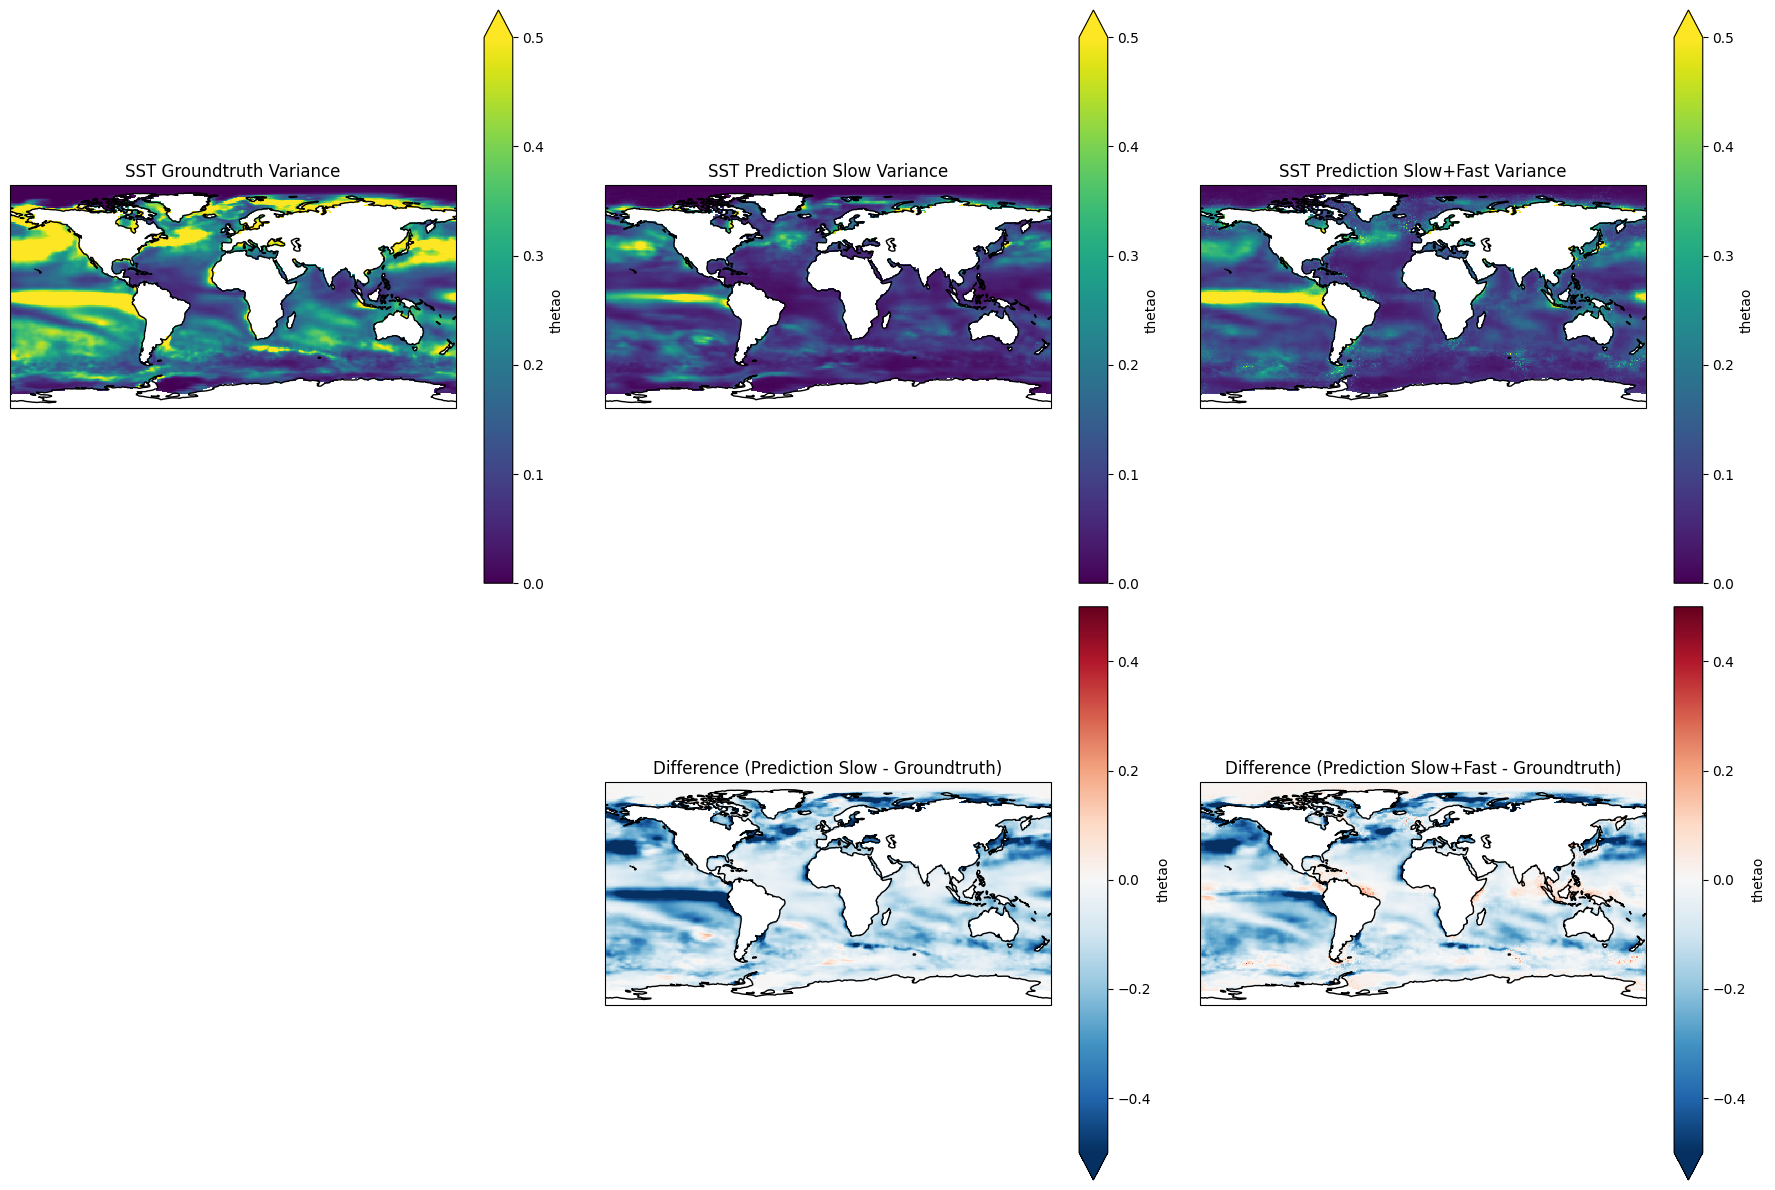

In [14]:
# Define a much smaller range for the colorbar
vmin = 0  # Minimum colorbar value
vmax = 0.5  # Maximum colorbar value

# Define the figure with 3 columns and 2 rows (for the variance and difference plots)
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Row 1 - Variance plots

# Compute and plot the variance of sst_groundtruth over time with the reduced colorbar range
sst_groundtruth.var('time').plot(ax=axs[0, 0], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('SST Groundtruth Variance')
axs[0, 0].coastlines()

# Compute and plot the variance of sst_prediction_temp over time with the reduced colorbar range
sst_prediction_temp.var('time').plot(ax=axs[0, 1], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('SST Prediction Slow Variance')
axs[0, 1].coastlines()

# Compute and plot the variance of sst_prediction_all over time with the reduced colorbar range
sst_prediction_all.var('time').plot(ax=axs[0, 2], cmap='viridis', vmin=vmin, vmax=vmax)
axs[0, 2].set_title('SST Prediction Slow+Fast Variance')
axs[0, 2].coastlines()

# Row 2 - Difference plots

# Compute and plot the difference: sst_groundtruth - sst_prediction_temp
(sst_prediction_temp.var('time') - sst_groundtruth.var('time')).plot(ax=axs[1, 1], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 1].set_title('Difference (Prediction Slow - Groundtruth)')
axs[1, 1].coastlines()

# Compute and plot the difference: sst_groundtruth - sst_prediction_all
(sst_prediction_all.var('time') - sst_groundtruth.var('time')).plot(ax=axs[1, 2], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axs[1, 2].set_title('Difference (Prediction Slow+Fast - Groundtruth)')
axs[1, 2].coastlines()

# Remove the first column in the second row (to keep the layout clean)
axs[1, 0].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

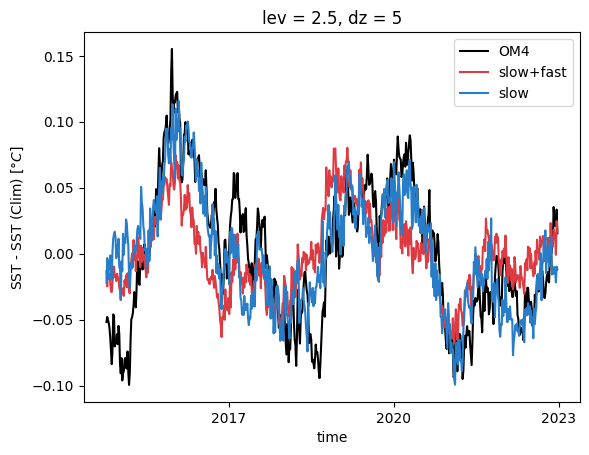

In [126]:
sst_groundtruth = sst_groundtruth.rename('SST - SST (Clim)')
sst_groundtruth = sst_groundtruth.assign_attrs(units = r'$\degree C$')
sst_groundtruth.plot(label="OM4", c='k')

sst_prediction_temp = sst_prediction_temp.rename('SST - SST (Clim)')
sst_prediction_temp = sst_prediction_temp.assign_attrs(units = r'$\degree C$')
sst_prediction_temp.plot(label="slow+fast", c=color_1)

sst_prediction_all = sst_prediction_all.rename('SST - SST (Clim)')
sst_prediction_all = sst_prediction_all.assign_attrs(units = r'$\degree C$')
sst_prediction_all.plot(label="slow", c=color_2)

plt.legend()
plt.show()